<a href="https://colab.research.google.com" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from torch.utils.data import TensorDataset, DataLoader
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('data/bank_transactions_data_2_augmented_clean_2.csv')
df.columns = df.columns.str.strip()
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'], format='mixed')
df['Month'] = df['TransactionDate'].dt.month
df['Hour'] = df['TransactionDate'].dt.hour
df['SuspiciousLogin'] = (df['LoginAttempts'] >= 3).astype(int)

In [3]:
df

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,Month,Hour,SuspiciousLogin
0,TX000001,AC00128,14.09,2023-04-11 16:29:00,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,4,16,0
1,TX000002,AC00455,376.24,2023-06-27 16:44:00,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,6,16,0
2,TX000003,AC00019,126.29,2023-07-10 18:16:00,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,7,18,0
3,TX000004,AC00070,184.50,2023-05-05 16:32:00,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,5,16,0
4,TX000005,AC00411,13.45,2023-10-16 17:51:00,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,10,17,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,TX049996,AC00314,69.23,2025-01-28 00:00:00,Debit,Las Vegas,D000546,44.67.137.125,M097,Online,69,Doctor,69,1,6020.29,1,0,0
49996,TX049997,AC00370,514.53,2022-01-23 00:00:00,Debit,Houston,D000589,140.212.253.222,M061,ATM,46,Engineer,143,1,6371.51,1,0,0
49997,TX049998,AC00277,118.39,2022-11-08 00:00:00,Debit,Omaha,D000217,152.140.239.181,M029,Online,33,Doctor,296,1,749.34,11,0,0
49998,TX049999,AC00007,446.99,2025-04-20 00:00:00,Debit,Las Vegas,D000327,131.41.45.13,M082,ATM,58,Doctor,11,1,10915.11,4,0,0


In [4]:
df['SuspiciousLogin'].value_counts()

SuspiciousLogin
0    48076
1     1924
Name: count, dtype: int64

In [ ]:
df = df.dropna()

# Replace inf/-inf with NaN, then drop or replace them
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()

In [6]:
df.isnull().sum().values

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   TransactionID        50000 non-null  object        
 1   AccountID            50000 non-null  object        
 2   TransactionAmount    50000 non-null  float64       
 3   TransactionDate      50000 non-null  datetime64[ns]
 4   TransactionType      50000 non-null  object        
 5   Location             50000 non-null  object        
 6   DeviceID             50000 non-null  object        
 7   IP Address           50000 non-null  object        
 8   MerchantID           50000 non-null  object        
 9   Channel              50000 non-null  object        
 10  CustomerAge          50000 non-null  int64         
 11  CustomerOccupation   50000 non-null  object        
 12  TransactionDuration  50000 non-null  int64         
 13  LoginAttempts        50000 non-

In [8]:
# Encode categorical features
le = LabelEncoder()
df_ml = df.copy()
for col in ['TransactionType', 'Channel', 'CustomerOccupation', 'Location']:
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))

In [9]:
df_ml.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   TransactionID        50000 non-null  object        
 1   AccountID            50000 non-null  object        
 2   TransactionAmount    50000 non-null  float64       
 3   TransactionDate      50000 non-null  datetime64[ns]
 4   TransactionType      50000 non-null  int64         
 5   Location             50000 non-null  int64         
 6   DeviceID             50000 non-null  object        
 7   IP Address           50000 non-null  object        
 8   MerchantID           50000 non-null  object        
 9   Channel              50000 non-null  int64         
 10  CustomerAge          50000 non-null  int64         
 11  CustomerOccupation   50000 non-null  int64         
 12  TransactionDuration  50000 non-null  int64         
 13  LoginAttempts        50000 non-

In [10]:
df_ml['SuspiciousLogin'].unique()

array([0, 1])

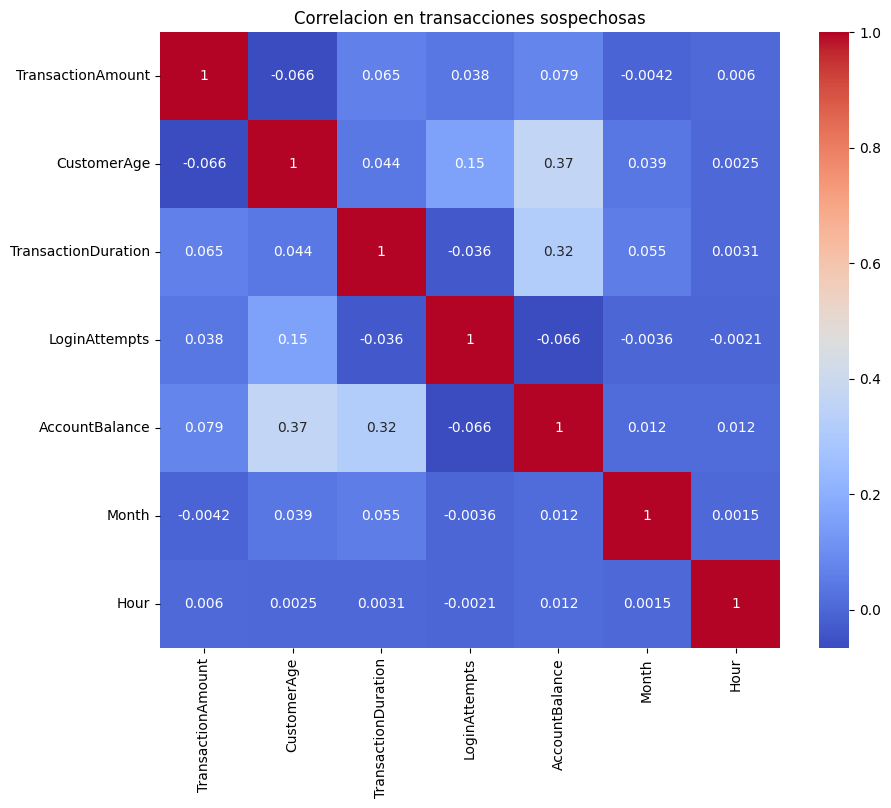

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlacion en transacciones sospechosas
num_cols = ['TransactionAmount', 'CustomerAge', 'TransactionDuration', 'LoginAttempts', 'AccountBalance', 'Month', 'Hour']
plt.figure(figsize=(10, 8))
sns.heatmap(df_ml[df_ml['SuspiciousLogin'] == 1][num_cols].corr(), cmap='coolwarm', annot=True)
plt.title('Correlacion en transacciones sospechosas')
plt.show()

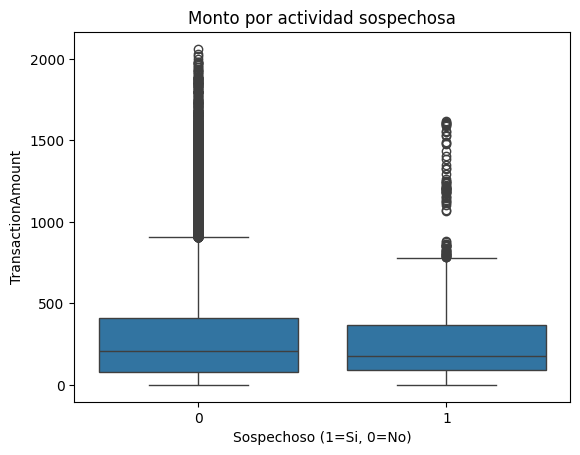

In [12]:
# Boxplot de monto por tipo de transaccion sospechosa
sns.boxplot(data=df_ml, x='SuspiciousLogin', y='TransactionAmount')
plt.title('Monto por actividad sospechosa')
plt.xlabel('Sospechoso (1=Si, 0=No)')
plt.show()

In [13]:
features = ['TransactionAmount', 'CustomerAge', 'TransactionDuration',
            'LoginAttempts', 'AccountBalance', 'TransactionType',
            'Channel', 'CustomerOccupation', 'Month', 'Hour']

X = df_ml[features].values
y = df_ml['SuspiciousLogin'].values

In [14]:
X.shape, y.shape, X.max(), X.min()

((50000, 10), (50000,), np.float64(14977.99), np.float64(0.0))

In [15]:
# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [18]:
y_pred = model.predict(X_test)

In [19]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy}')

Accuracy: 1.0


In [20]:
print(classification_report(y_test, y_pred, target_names=['Normal', 'Sospechoso']))

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      9595
  Sospechoso       1.00      1.00      1.00       405

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



Confusion Matrix:
[[9595    0]
 [   0  405]]


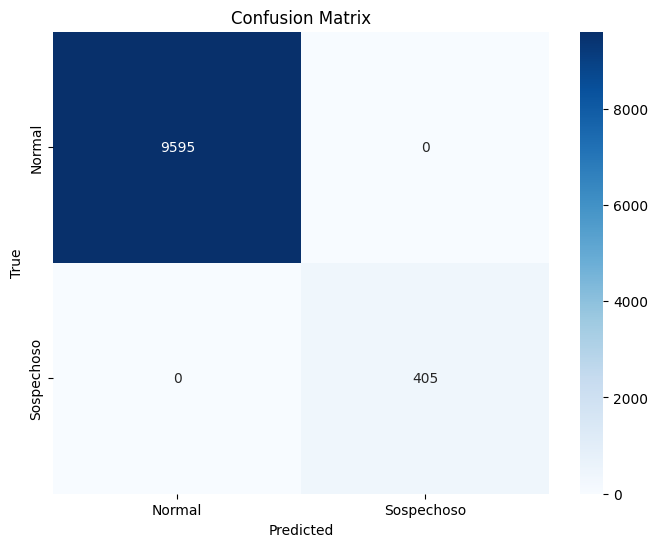

In [21]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:')
print(cm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Sospechoso'],
            yticklabels=['Normal', 'Sospechoso'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [22]:
feature_importances = model.feature_importances_
features_df = pd.DataFrame({
    'feature': features,
    'importance': feature_importances
})

In [23]:
features_df.sort_values('importance', ascending=False).head(10)

,feature,importance
3,LoginAttempts,0.943970
4,AccountBalance,0.017637
2,TransactionDuration,0.013985
0,TransactionAmount,0.009885
1,CustomerAge,0.009568
6,Channel,0.002560
7,CustomerOccupation,0.001137
5,TransactionType,0.000954
8,Month,0.000271
9,Hour,0.000034


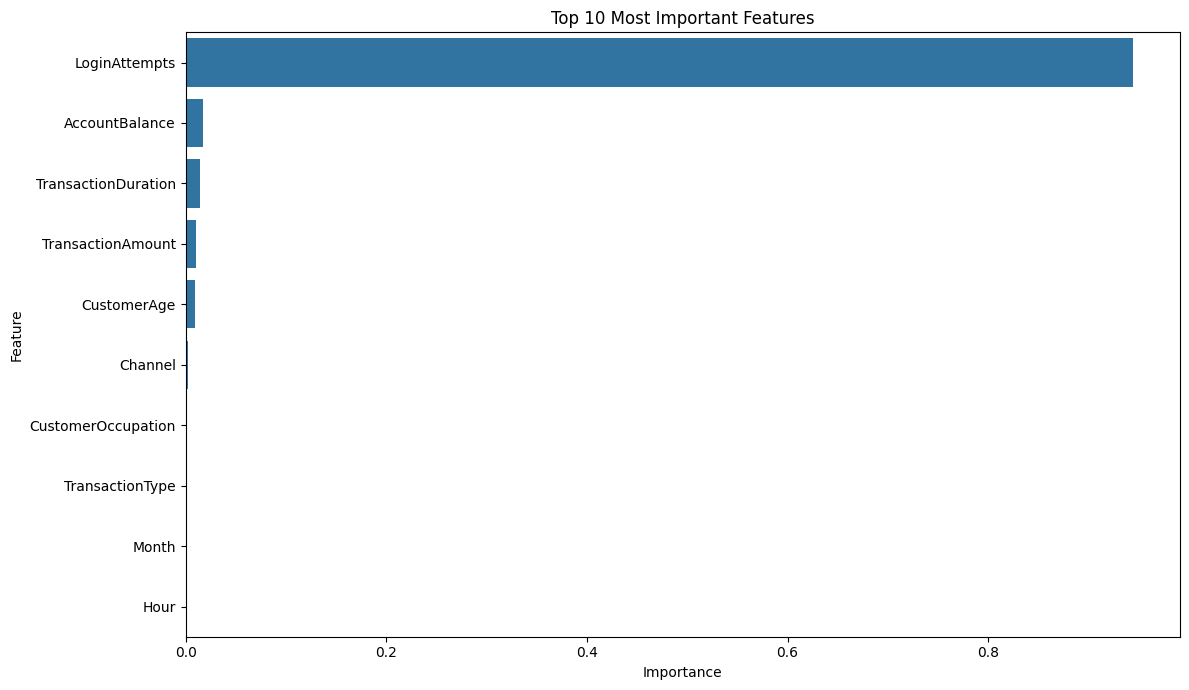

In [24]:
plt.figure(figsize=(12, 7))
sns.barplot(x='importance', y='feature', data=features_df.sort_values('importance', ascending=False))
plt.title('Top 10 Most Important Features')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [25]:
# Convert to tensors
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.long)

In [26]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_tensor, y_tensor, test_size=0.2, random_state=42)

In [27]:
# Create DataLoader
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)

In [28]:
# Define the neural network
class SimpleNN(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, output_dim=2):
        super(SimpleNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, output_dim)
        )

    def forward(self, x):
        return self.net(x)

In [29]:
model_nn = SimpleNN(X.shape[1], hidden_dim=128, output_dim=len(np.unique(y)))
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_nn.parameters(), lr=0.001)

In [30]:
# Training loop with loss tracking
epochs = 10
losses = []
for epoch in range(epochs):
    model_nn.train()
    epoch_loss = 0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model_nn(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    avg_loss = epoch_loss / len(train_loader)
    losses.append(avg_loss)
    print(f'Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f}')

Epoch 1/10 - Loss: 0.0210
Epoch 2/10 - Loss: 0.0007
Epoch 3/10 - Loss: 0.0003
Epoch 4/10 - Loss: 0.0002
Epoch 5/10 - Loss: 0.0004
Epoch 6/10 - Loss: 0.0001
Epoch 7/10 - Loss: 0.0001
Epoch 8/10 - Loss: 0.0005
Epoch 9/10 - Loss: 0.0000
Epoch 10/10 - Loss: 0.0000


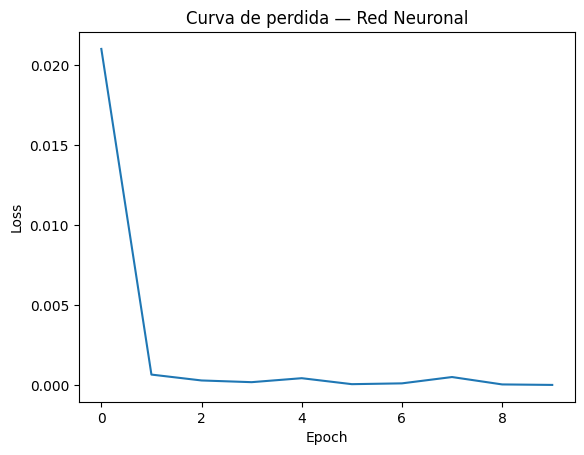

In [31]:
plt.plot(losses)
plt.title('Curva de perdida — Red Neuronal')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()